# Re-arange/Split Dataset into 60:20:20

In [115]:
from pathlib import Path
import re
import numpy as np

SEED = 42

data_dir = Path("../data/processed")

# Keep only: .npy files AND filename contains "LPPT"
all_npy = [p for p in data_dir.glob("*.npy") if "LPPT" in p.name]
name2path = {p.name: p for p in all_npy}

print(f"Found {len(all_npy)} LPPT .npy files in: {data_dir.resolve()}")


Found 20 LPPT .npy files in: C:\Users\lenovo\Desktop\A25\ISCF\Early-Fault-Detection-in-PV-A-Case-Study-on-the-GPVS-Faults-Dataset\data\processed


In [116]:
#   Handle X_{train,val,test}_LPPT* and matching Y_{train,val,test}_LPPT*. 
#   Merge into lists in split order: train -> val -> test (preserve sample order).

def load_npy(path: Path):
    # allow_pickle=True is safe for normal numeric arrays and required for object arrays
    return np.load(path, allow_pickle=True)

def extend_samples(X_list, Y_list, X_arr, Y_arr):
    assert len(X_arr) == len(Y_arr), f"Mismatched number of samples: X={len(X_arr)} vs Y={len(Y_arr)}"
    # Append per-sample to preserve internal order
    X_list.extend(list(X_arr))
    Y_list.extend(list(Y_arr))

# Stage 1 pattern: X_train/val/test_LPPT...
rx_stage1 = re.compile(r"^X_(train|val|test)_LPPT(.*)\.npy$")

groups = {}  # suffix -> {split: X_path}
for fname, fpath in name2path.items():
    m = rx_stage1.match(fname)
    if not m:
        continue
    split, suffix = m.group(1), m.group(2)  # keep suffix exactly as-is
    groups.setdefault(suffix, {})[split] = fpath

X_LPPT_list, Y_LPPT_list = [], []

# Deterministic and stable merge: process suffixes in sorted order,
# and within each suffix process splits in train->val->test order.
for suffix in sorted(groups.keys()):
    for split in ["train", "val", "test"]:
        x_path = groups[suffix].get(split)
        if x_path is None:
            continue

        y_name = f"Y_{split}_LPPT{suffix}.npy"
        y_path = name2path.get(y_name)
        if y_path is None:
            raise FileNotFoundError(f"Missing matching label file: {y_name} (for {x_path.name})")

        X_arr = load_npy(x_path)
        Y_arr = load_npy(y_path)
        extend_samples(X_LPPT_list, Y_LPPT_list, X_arr, Y_arr)

print(f"After stage1: len(X_LPPT_list)={len(X_LPPT_list)}, len(Y_LPPT_list)={len(Y_LPPT_list)}")


After stage1: len(X_LPPT_list)=1386, len(Y_LPPT_list)=1386


In [117]:
#   Handle X_test_FxL_LPPT* (x in 1..7) and matching Y_test_FxL_LPPT*.
#   Continue appending into the same lists (preserve sample order).

rx_stage2 = re.compile(r"^X_test_F([1-7])L_LPPT(.*)\.npy$")

# Deterministic order: sort by full filename (covers x and suffix ordering)
x2_files = sorted([p for p in all_npy if rx_stage2.match(p.name)], key=lambda p: p.name)

for x_path in x2_files:
    m = rx_stage2.match(x_path.name)
    x_digit, suffix = m.group(1), m.group(2)

    y_name = f"Y_test_F{x_digit}L_LPPT{suffix}.npy"
    y_path = name2path.get(y_name)
    if y_path is None:
        raise FileNotFoundError(f"Missing matching label file: {y_name} (for {x_path.name})")

    X_arr = load_npy(x_path)
    Y_arr = load_npy(y_path)
    extend_samples(X_LPPT_list, Y_LPPT_list, X_arr, Y_arr)

print(f"After stage2: len(X_LPPT_list)={len(X_LPPT_list)}, len(Y_LPPT_list)={len(Y_LPPT_list)}")

After stage2: len(X_LPPT_list)=4703, len(Y_LPPT_list)=4703


In [118]:
rng = np.random.default_rng(SEED)

N = len(X_LPPT_list)
assert N == len(Y_LPPT_list)

indices = np.arange(N)
rng.shuffle(indices)

n_train = int(0.6 * N)
n_val   = int(0.2 * N)

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

X_train = np.array([X_LPPT_list[i] for i in train_idx])
Y_train = np.array([str(Y_LPPT_list[i]) for i in train_idx])

X_val = np.array([X_LPPT_list[i] for i in val_idx])
Y_val = np.array([str(Y_LPPT_list[i]) for i in val_idx])

X_test = np.array([X_LPPT_list[i] for i in test_idx])
Y_test = np.array([str(Y_LPPT_list[i]) for i in test_idx])

print("X_train shape:", X_train.shape)
print("X_val   shape:", X_val.shape)
print("X_test  shape:", X_test.shape)

print("Y_train classes:", np.unique(Y_train))

X_train shape: (2821, 200, 13)
X_val   shape: (940, 200, 13)
X_test  shape: (942, 200, 13)
Y_train classes: ['F0L' 'F1L' 'F2L' 'F3L' 'F4L' 'F5L' 'F6L' 'F7L']


# Time-series features (window_len = 200) → XGBoost (5-fold CV)

For each sample, each original channel (13 features) has 200 points.
We convert each channel into a fixed feature vector, so (N, 200, 13) → (N, 13 × K).

### Per-channel engineered features (from 200 points)

- mean, std, min, max, median, q25, q75, iqr

- skew (distribution asymmetry)

- kurt (distribution “tailedness”, excess kurtosis)

- rms, abs_mean, abs_max, energy, ptp

- zcr (zero-crossing rate after mean-centering)

- slope_mean, slope_std (stats of diff(x))

- ac1 (lag-1 autocorrelation)

- Frequency-domain (rFFT power)

- domfreq (max-power frequency bin, no DC)

- spec_centroid (spectral center)

- spec_bandwidth (spectral spread)

- spec_entropy (spectrum flatness)

- bp_low / bp_mid / bp_high (band powers, normalized bands)

### Training

Use XGBoost for 8-class classification (F0L–F7L).
Tune hyperparameters with 5-fold stratified CV.

In [119]:
from sklearn.preprocessing import LabelEncoder

def extract_ts_features(X: np.ndarray, eps: float = 1e-12):
    """
    X: (N, T, C) e.g. (N,200,13)
    returns:
      feats: (N, C*K)  (flattened per-channel features)
      feat_names: list[str]
      K: number of features per channel
    """
    X = np.asarray(X, dtype=np.float32)
    assert X.ndim == 3, f"Expected (N,T,C), got {X.shape}"
    N, T, C = X.shape

    # time-domain
    mean = X.mean(axis=1)
    std  = X.std(axis=1) + eps
    vmin = X.min(axis=1)
    vmax = X.max(axis=1)
    med  = np.median(X, axis=1)
    q25  = np.quantile(X, 0.25, axis=1)
    q75  = np.quantile(X, 0.75, axis=1)
    iqr  = q75 - q25

    xc = X - mean[:, None, :]
    m2 = (xc**2).mean(axis=1) + eps
    m3 = (xc**3).mean(axis=1)
    m4 = (xc**4).mean(axis=1)
    skew = m3 / (m2**1.5)
    kurt = m4 / (m2**2) - 3.0

    rms = np.sqrt((X**2).mean(axis=1) + eps)
    abs_mean = np.abs(X).mean(axis=1)
    abs_max  = np.abs(X).max(axis=1)
    energy   = (X**2).sum(axis=1)
    ptp      = vmax - vmin

    signbit = np.signbit(xc)
    zc = np.diff(signbit.astype(np.int8), axis=1)
    zcr = (zc != 0).mean(axis=1)

    dX = np.diff(X, axis=1)
    slope_mean = dX.mean(axis=1)
    slope_std  = dX.std(axis=1)

    x0 = xc[:, :-1, :]
    x1 = xc[:,  1:, :]
    ac1 = (x0 * x1).mean(axis=1) / (m2 + eps)

    # frequency-domain (rFFT)
    fft = np.fft.rfft(xc, axis=1)
    power = (fft.real**2 + fft.imag**2).astype(np.float32)
    freqs = np.fft.rfftfreq(T, d=1.0).astype(np.float32)

    power_nd = power[:, 1:, :]  # drop DC
    freqs_nd = freqs[1:]
    psum = power_nd.sum(axis=1) + eps
    p = power_nd / psum[:, None, :]

    dom_idx = np.argmax(power_nd, axis=1)
    domfreq = freqs_nd[dom_idx]
    centroid = (p * freqs_nd[None, :, None]).sum(axis=1)
    bandwidth = np.sqrt((p * (freqs_nd[None, :, None] - centroid[:, None, :])**2).sum(axis=1) + eps)
    sentropy = -(p * np.log(p + eps)).sum(axis=1) / np.log(p.shape[1] + eps)

    def band_power(f_lo, f_hi):
        mask = (freqs_nd >= f_lo) & (freqs_nd < f_hi)
        if not np.any(mask):
            return np.zeros((N, C), dtype=np.float32)
        return power_nd[:, mask, :].sum(axis=1)

    bp_low  = band_power(0.00, 0.10)
    bp_mid  = band_power(0.10, 0.25)
    bp_high = band_power(0.25, 0.50)

    feats_per_ch = [
        mean, std, vmin, vmax, med, q25, q75, iqr, skew, kurt,
        rms, abs_mean, abs_max, energy, ptp, zcr, slope_mean, slope_std, ac1,
        domfreq, centroid, bandwidth, sentropy, bp_low, bp_mid, bp_high
    ]
    base_names = [
        "mean","std","min","max","median","q25","q75","iqr","skew","kurt",
        "rms","abs_mean","abs_max","energy","ptp","zcr","slope_mean","slope_std","ac1",
        "domfreq","spec_centroid","spec_bandwidth","spec_entropy","bp_low","bp_mid","bp_high"
    ]
    K = len(base_names)

    feats = np.stack(feats_per_ch, axis=-1)   # (N,C,K)
    feats = feats.reshape(N, -1).astype(np.float32)  # (N,C*K)
    feat_names = [f"ch{c}_{bn}" for c in range(C) for bn in base_names]
    return feats, feat_names, K

# label encoding
le = LabelEncoder()
y_train_int = le.fit_transform([str(x) for x in Y_train])
y_val_int   = le.transform([str(x) for x in Y_val])

X_train_feat, feat_names, K = extract_ts_features(X_train)
X_val_feat, _, _            = extract_ts_features(X_val)

print("Original X_train shape:", X_train.shape)
print("Engineered X_train_feat shape:", X_train_feat.shape, f"(K={K} per channel, C={X_train.shape[-1]})")
print("Original X_val shape:", X_val.shape)
print("Engineered X_val_feat shape:", X_val_feat.shape)
print("Classes:", list(le.classes_))

Original X_train shape: (2821, 200, 13)
Engineered X_train_feat shape: (2821, 338) (K=26 per channel, C=13)
Original X_val shape: (940, 200, 13)
Engineered X_val_feat shape: (940, 338)
Classes: [np.str_('F0L'), np.str_('F1L'), np.str_('F2L'), np.str_('F3L'), np.str_('F4L'), np.str_('F5L'), np.str_('F6L'), np.str_('F7L')]


In [120]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

n_classes = len(le.classes_)

base = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 600, 900],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0.0, 1.0],
    "reg_alpha": [0.0, 1e-2],
    "reg_lambda": [1.0, 3.0],
}

# param_dist = {
#     "n_estimators": [300],
#     "max_depth": [3],
#     "learning_rate": [0.01],
#     "subsample": [1.0],
#     "colsample_bytree": [1.0],
#     "min_child_weight": [5],
#     "gamma": [1.0],
#     "reg_alpha": [1e-2],
#     "reg_lambda": [1.0],
# }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

search.fit(X_val_feat, y_val_int)

best_params = search.best_params_
print("Best CV score on VAL (5-fold, f1_macro):", search.best_score_)
print("Best params:", best_params)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV score on VAL (5-fold, f1_macro): 1.0
Best params: {'subsample': 0.8, 'reg_lambda': 3.0, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.0, 'colsample_bytree': 0.8}


In [121]:
y_test_int = le.transform([str(x) for x in Y_test])
X_test_feat, _, _ = extract_ts_features(X_test)

print("Original X_test shape:", X_test.shape)
print("Engineered X_test_feat shape:", X_test_feat.shape)

Original X_test shape: (942, 200, 13)
Engineered X_test_feat shape: (942, 338)


In [122]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

final_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

final_model.fit(X_train_feat, y_train_int)

y_pred = final_model.predict(X_test_feat)

print("Test overall accuracy:", accuracy_score(y_test_int, y_pred))
print("\nPer-class precision/recall/F1 on TEST:")
print(classification_report(y_test_int, y_pred, target_names=list(le.classes_), digits=4))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test_int, y_pred))

Test overall accuracy: 0.9989384288747346

Per-class precision/recall/F1 on TEST:
              precision    recall  f1-score   support

         F0L     1.0000    1.0000    1.0000       284
         F1L     1.0000    1.0000    1.0000        77
         F2L     1.0000    1.0000    1.0000       100
         F3L     1.0000    0.9615    0.9804        26
         F4L     0.9907    1.0000    0.9953       106
         F5L     1.0000    1.0000    1.0000       142
         F6L     1.0000    1.0000    1.0000        97
         F7L     1.0000    1.0000    1.0000       110

    accuracy                         0.9989       942
   macro avg     0.9988    0.9952    0.9970       942
weighted avg     0.9989    0.9989    0.9989       942

Confusion matrix (rows=true, cols=pred):
[[284   0   0   0   0   0   0   0]
 [  0  77   0   0   0   0   0   0]
 [  0   0 100   0   0   0   0   0]
 [  0   0   0  25   1   0   0   0]
 [  0   0   0   0 106   0   0   0]
 [  0   0   0   0   0 142   0   0]
 [  0   0   0   

# Assess the importcance of each parameter

In [123]:
booster = final_model.get_booster()

# 'gain' usually most informative; also try: 'weight', 'cover'
imp = booster.get_score(importance_type="gain")

# XGBoost feature keys are like: f0, f1, ...
items = sorted(imp.items(), key=lambda x: x[1], reverse=True)

topk = 30
for k, v in items[:topk]:
    idx = int(k[1:])  # "f123" -> 123
    print(f"{idx:4d}  {feat_names[idx]:25s}  gain={v:.6f}")

   4  ch0_median                 gain=379.902435
  39  ch1_energy                 gain=376.426178
 133  ch5_max                    gain=273.644775
  58  ch2_q75                    gain=142.531586
  37  ch1_abs_mean               gain=134.021255
  82  ch3_median                 gain=119.709511
 141  ch5_abs_mean               gain=113.109764
  36  ch1_rms                    gain=112.660820
  54  ch2_min                    gain=111.695076
  90  ch3_abs_max                gain=108.694778
  64  ch2_abs_max                gain=105.824493
   0  ch0_mean                   gain=95.569664
  79  ch3_std                    gain=93.331154
 134  ch5_median                 gain=92.209595
  57  ch2_q25                    gain=91.281944
  81  ch3_max                    gain=85.440063
 130  ch5_mean                   gain=80.131218
 115  ch4_abs_mean               gain=79.850960
   2  ch0_min                    gain=77.703392
   5  ch0_q25                    gain=74.837822
  80  ch3_min                

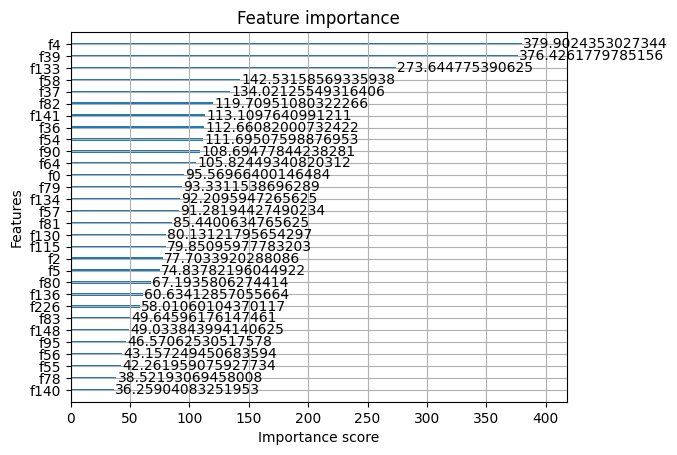

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
plot_importance(final_model, importance_type="gain", max_num_features=30)
plt.show()   